In [40]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Linear Regression for one variable

In [2]:
#read dataset
data = np.genfromtxt('dataset1.csv', delimiter=',', skip_header=1)

In [3]:
data

array([[ 6.1101 , 17.592  ],
       [ 5.5277 ,  9.1302 ],
       [ 8.5186 , 13.662  ],
       [ 7.0032 , 11.854  ],
       [ 5.8598 ,  6.8233 ],
       [ 8.3829 , 11.886  ],
       [ 7.4764 ,  4.3483 ],
       [ 8.5781 , 12.     ],
       [ 6.4862 ,  6.5987 ],
       [ 5.0546 ,  3.8166 ],
       [ 5.7107 ,  3.2522 ],
       [14.164  , 15.505  ],
       [ 5.734  ,  3.1551 ],
       [ 8.4084 ,  7.2258 ],
       [ 5.6407 ,  0.71618],
       [ 5.3794 ,  3.5129 ],
       [ 6.3654 ,  5.3048 ],
       [ 5.1301 ,  0.56077],
       [ 6.4296 ,  3.6518 ],
       [ 7.0708 ,  5.3893 ],
       [ 6.1891 ,  3.1386 ],
       [20.27   , 21.767  ],
       [ 5.4901 ,  4.263  ],
       [ 6.3261 ,  5.1875 ],
       [ 5.5649 ,  3.0825 ],
       [18.945  , 22.638  ],
       [12.828  , 13.501  ],
       [10.957  ,  7.0467 ],
       [13.176  , 14.692  ],
       [22.203  , 24.147  ],
       [ 5.2524 , -1.22   ],
       [ 6.5894 ,  5.9966 ],
       [ 9.2482 , 12.134  ],
       [ 5.8918 ,  1.8495 ],
       [ 8.211

In [4]:
X=data[:,0]
y=data[:,1]

In [5]:
#Normalization
X= X/ X.max()
y=y/y.max()

In [6]:
# Add bias term (intercept) by stacking a column of ones as the first feature
X = np.column_stack((np.ones_like(X), X))


In [7]:
# Compute the Mean Squared Error (MSE) cost:
# - X: input feature matrix (with bias column included)
# - y: true target values
# - theta: parameter vector
# The cost is: (1 / 2m) * Σ (h(x) - y)^2
def cost_function(X, y, theta):
    predictions = X.dot(theta)     
    error = predictions - y       
    cost = np.sum(error**2) / (2 * len(X))  
    return cost


In [9]:
def closed_form(X, y):
        # compute θ using normal equation (θ = (XᵀX)⁻¹ Xᵀ y)
        theta_closed_form = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

        # compute predictions using closed‑form θ
        y_closed_form = np.dot(X, theta_closed_form)

        return theta_closed_form, y_closed_form


In [10]:
def stochastic_gradient_descent(X, y, learning_rate, num_iterations):
    # init θ and cost history
    theta_sgd = np.zeros(X.shape[1])
    costs = np.zeros(num_iterations)

    for iteration in range(num_iterations):
        for i in range(X.shape[0]):
            h_theta = np.dot(X[i], theta_sgd)

            # compute error for current sample
            error = h_theta - y[i]

            # SGD update rule
            theta_sgd -= learning_rate * error * X[i]

        # store cost after each epoch
        costs[iteration] = cost_function(X, y, theta_sgd)

    # compute predictions
    y_sgd = np.dot(X, theta_sgd)

    return theta_sgd, y_sgd, costs


In [11]:
def batch_gradient_descent(X, y, learning_rate, num_iterations):
    # init θ and cost history
    theta_batch = np.zeros(X.shape[1])
    costs = np.zeros(num_iterations)

    for iteration in range(num_iterations):
        h_theta = np.dot(X, theta_batch)

        # vectorized error
        errors = h_theta - y

        # batch gradient update
        gradient = np.dot(X.T, errors)
        theta_batch -= (learning_rate / X.shape[0]) * gradient

        # track cost per epoch
        costs[iteration] = cost_function(X, y, theta_batch)

    # compute predictions
    y_batch = np.dot(X, theta_batch)

    return theta_batch, y_batch, costs


In [12]:
theta_closed_form,y_closed_form=closed_form(X,y)
theta_sgd,y_sgd,sgd_costs=stochastic_gradient_descent(X, y,0.01, 1500)
theta_batch, y_batch,batch_costs=batch_gradient_descent(X, y,0.01, 1500)

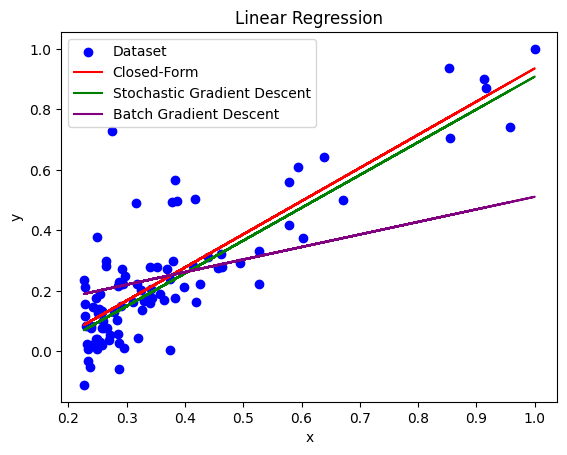

In [13]:
# Plot the dataset and the fitted models

# Scatter plot of the raw data points (X[:,1] is the feature column after bias term)
plt.scatter(X[:, 1], y, color='blue', label='Dataset')

# Plot predictions from the closed‑form analytical solution
plt.plot(X[:, 1], y_closed_form, color='red', label='Closed-Form')

# Plot predictions from Stochastic Gradient Descent (SGD)
plt.plot(X[:, 1], y_sgd, color='green', label='Stochastic Gradient Descent')

# Plot predictions from Batch Gradient Descent (BGD)
plt.plot(X[:, 1], y_batch, color='purple', label='Batch Gradient Descent')


plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.show()


# Linear Regression for multiple variable

In [44]:
train_data = pd.read_csv('train.csv')
test_data=pd.read_csv('test.csv')
test_data

,age,gender,bmi,children,smoker,region,charges
0,30,male,22.990,2,yes,northwest,17361.76610
1,24,male,32.700,0,yes,southwest,34472.84100
2,24,male,25.800,0,no,southwest,1972.95000
3,48,male,29.600,0,no,southwest,21232.18226
4,47,male,19.190,1,no,northeast,8627.54110
...,...,...,...,...,...,...,...
145,52,male,32.775,3,no,northwest,11289.10925
146,60,male,32.800,0,yes,southwest,52590.82939
147,20,female,31.920,0,no,northwest,2261.56880
148,55,male,21.500,1,no,southwest,10791.96000


**EDA**

In [46]:
#Basic Dataset Overview

print("Shape:", train_data.shape)
print("\nData Types:")
print(train_data.dtypes)

print("\nMissing Values:")
print(train_data.isnull().sum())



Shape: (1000, 7)

Data Types:
age           int64
gender       object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
gender      0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [47]:
#Statistical Summary
train_data.describe()


,age,bmi,children,charges
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,39.615000,30.86338,1.080000,13075.755883
std,14.153908,6.04744,1.198765,11985.924552
min,18.000000,15.96000,0.000000,1121.873900
25%,27.000000,26.60000,0.000000,4719.683425
50%,40.000000,30.59000,1.000000,9283.021300
75%,52.000000,35.11250,2.000000,15882.795438
max,64.000000,50.38000,5.000000,63770.428010


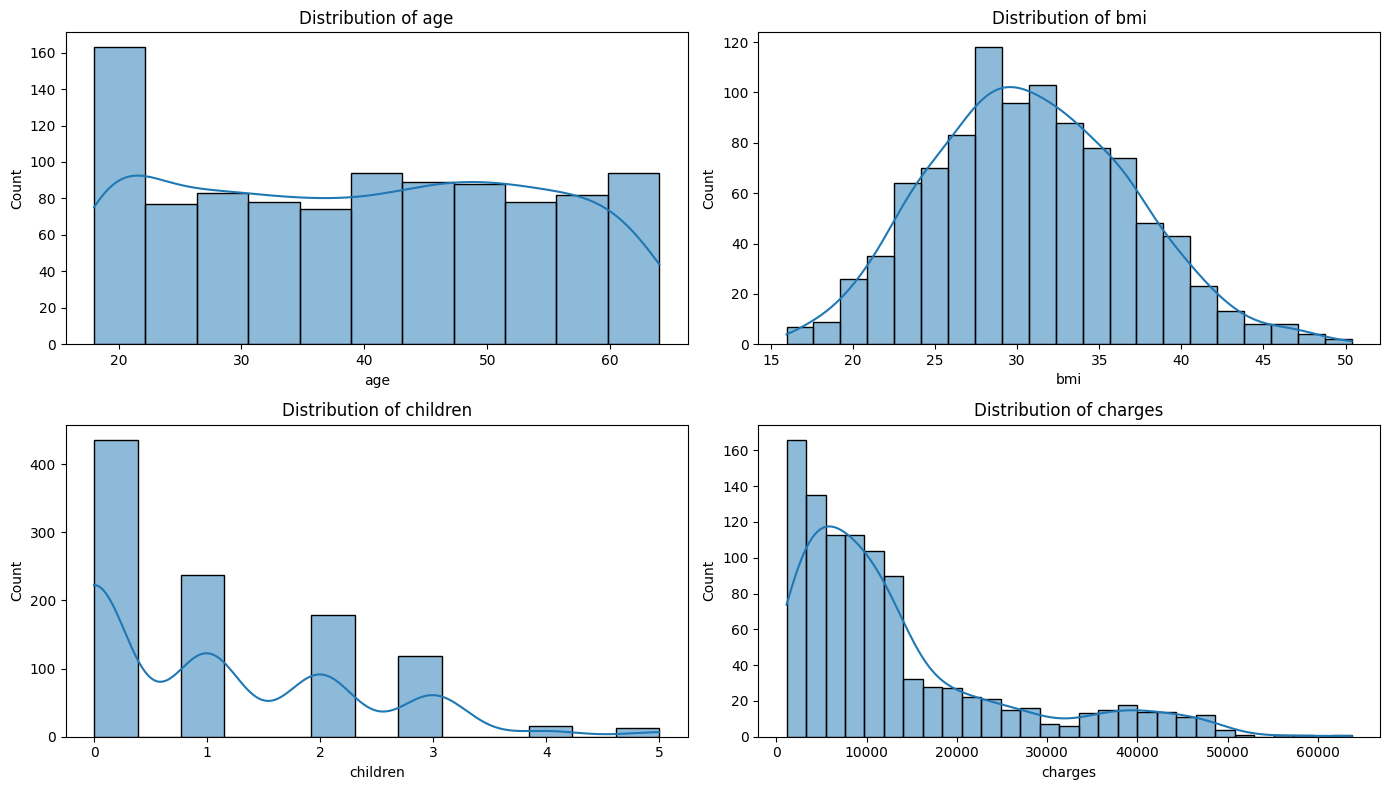

In [49]:
#Distribution of Numerical Features
numeric_cols = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(train_data[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


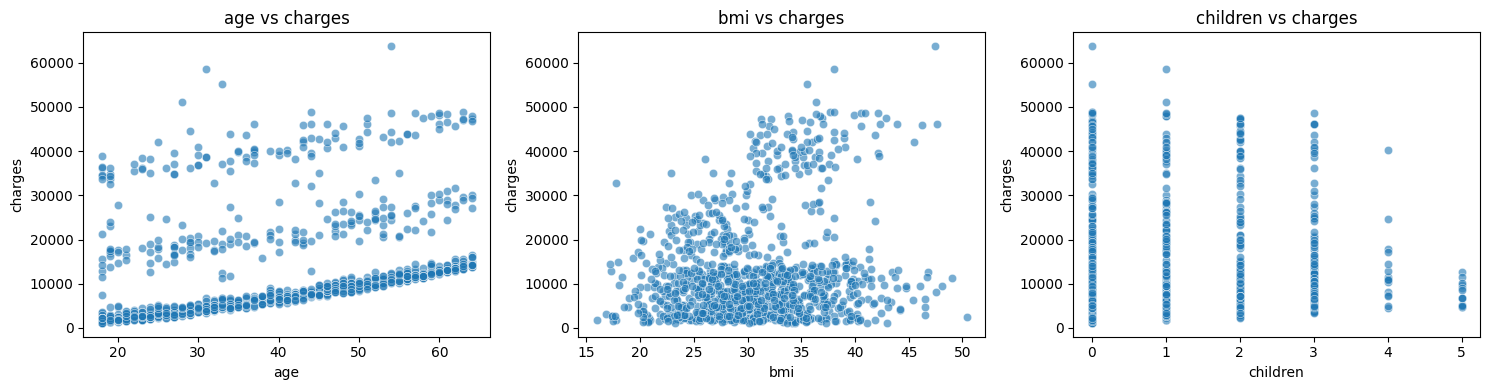

In [51]:
#Relationship with Target (charges)
features_to_check = ['age', 'bmi', 'children']

plt.figure(figsize=(15, 4))
for i, col in enumerate(features_to_check, 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(x=train_data[col], y=train_data['charges'], alpha=0.6)
    plt.title(f"{col} vs charges")
plt.tight_layout()
plt.show()


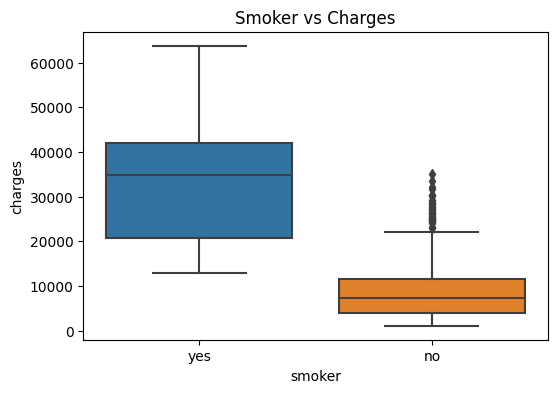

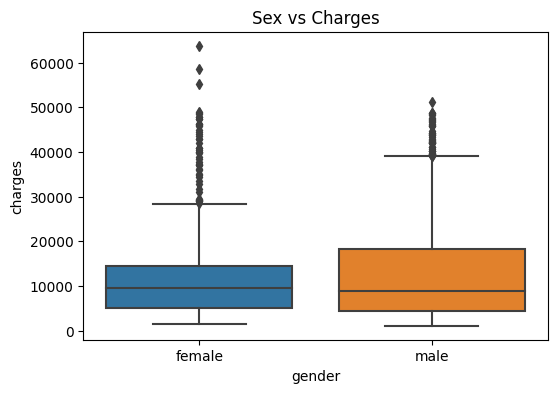

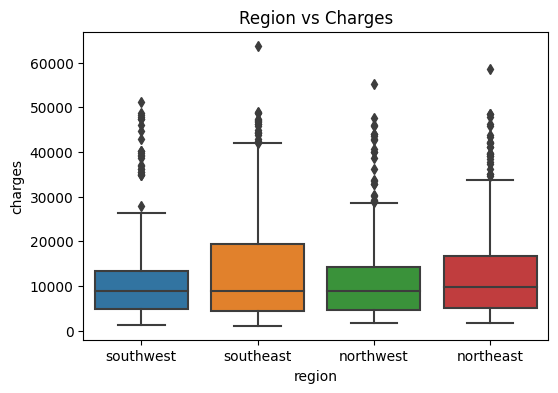

In [54]:
#Categorical Features vs Target
plt.figure(figsize=(6, 4))
sns.boxplot(x=train_data['smoker'], y=train_data['charges'])
plt.title("Smoker vs Charges")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x=train_data['gender'], y=train_data['charges'])
plt.title("Sex vs Charges")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x=train_data['region'], y=train_data['charges'])
plt.title("Region vs Charges")
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_8172\1750564024.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")


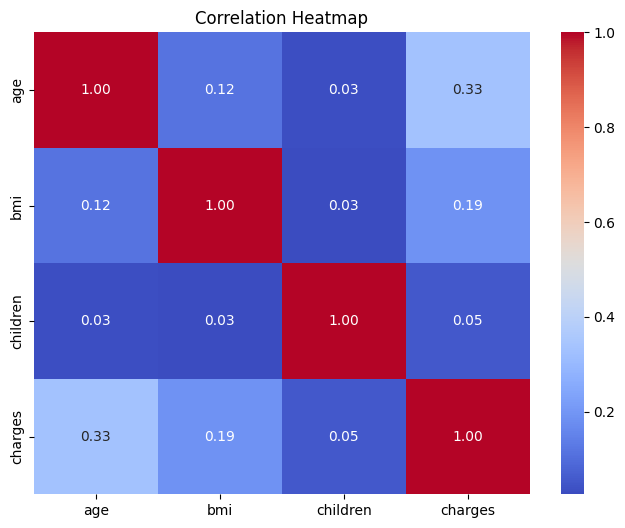

In [55]:
#Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(train_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [15]:
# Convert the 'gender' column from categorical to numeric (male → 0, female → 1)
train_data['gender'] = train_data['gender'].replace({'male': 0, 'female': 1})
test_data['gender'] = test_data['gender'].replace({'male': 0, 'female': 1})

# Convert the 'smoker' column from categorical to numeric (no → 0, yes → 1)
train_data['smoker'] = train_data['smoker'].replace({'no': 0, 'yes': 1})
test_data['smoker'] = test_data['smoker'].replace({'no': 0, 'yes': 1})


In [16]:
# One‑hot encode the categorical column 'region' and add the resulting dummy variables to the dataset
train_data = pd.get_dummies(train_data, columns=['region'])
test_data = pd.get_dummies(test_data, columns=['region'])


In [18]:
# Create a new feature 'bmi2' by squaring the 'bmi' column (useful for capturing nonlinear relationships)
train_data['bmi2'] = train_data['bmi'] ** 2
test_data['bmi2'] = test_data['bmi'] ** 2

columns_to_drop = ["bmi"]
train_data = train_data.drop(columns=columns_to_drop)
test_data = test_data.drop(columns=columns_to_drop)
train_data


,age,gender,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi2
0,19,1,0,1,16884.92400,0,0,0,1,778.410000
1,18,0,1,0,1725.55230,0,0,1,0,1140.412900
2,28,0,3,0,4449.46200,0,0,1,0,1089.000000
3,33,0,0,0,21984.47061,0,1,0,0,515.517025
4,32,0,0,0,3866.85520,0,1,0,0,834.054400
...,...,...,...,...,...,...,...,...,...,...
995,39,1,3,0,7986.47525,1,0,0,0,541.725625
996,39,1,3,0,7418.52200,0,0,0,1,1162.810000
997,63,1,0,0,13887.96850,0,0,1,0,1357.922500
998,33,1,3,0,6551.75010,1,0,0,0,1316.964100


In [19]:
# Move the 'charges' column to the end of the dataframe for better organization
charges_column = train_data.pop("charges")         
charges_column_tests = test_data.pop("charges")     

train_data.insert(len(train_data.columns), "charges", charges_column)              
test_data.insert(len(test_data.columns), "charges", charges_column_tests)         


In [21]:
X_train=train_data.iloc[:, :-1]
y_train=train_data.iloc[:, -1]
X_train['X0'] = 1
X_train

,age,gender,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,bmi2,X0
0,19,1,0,1,0,0,0,1,778.410000,1
1,18,0,1,0,0,0,1,0,1140.412900,1
2,28,0,3,0,0,0,1,0,1089.000000,1
3,33,0,0,0,0,1,0,0,515.517025,1
4,32,0,0,0,0,1,0,0,834.054400,1
...,...,...,...,...,...,...,...,...,...,...
995,39,1,3,0,1,0,0,0,541.725625,1
996,39,1,3,0,0,0,0,1,1162.810000,1
997,63,1,0,0,0,0,1,0,1357.922500,1
998,33,1,3,0,1,0,0,0,1316.964100,1


In [22]:
X_test=test_data.iloc[:, :-1]
y_test=test_data.iloc[:, -1]
X_test['X0'] = 1
X_t=X_train.values
X_t

array([[1.90000000e+01, 1.00000000e+00, 0.00000000e+00, ...,
        1.00000000e+00, 7.78410000e+02, 1.00000000e+00],
       [1.80000000e+01, 0.00000000e+00, 1.00000000e+00, ...,
        0.00000000e+00, 1.14041290e+03, 1.00000000e+00],
       [2.80000000e+01, 0.00000000e+00, 3.00000000e+00, ...,
        0.00000000e+00, 1.08900000e+03, 1.00000000e+00],
       ...,
       [6.30000000e+01, 1.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 1.35792250e+03, 1.00000000e+00],
       [3.30000000e+01, 1.00000000e+00, 3.00000000e+00, ...,
        0.00000000e+00, 1.31696410e+03, 1.00000000e+00],
       [3.60000000e+01, 1.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 7.22803225e+02, 1.00000000e+00]])

In [23]:
#Normalization

X_train['age'] = X_train['age'] / X_train['age'].max()
X_train['bmi2'] = X_train['bmi2'] / X_train['bmi2'].max()
X_train['children'] = X_train['children'] / X_train['children'].max()
y_train = y_train/y_train.max()

X_test['age'] = X_test['age'] / X_test['age'].max()
X_test['bmi2'] = X_test['bmi2'] / X_test['bmi2'].max()
X_test['children'] = X_test['children'] / X_test['children'].max()
y_test = y_test/y_test.max()

In [25]:
def closed_form(X, y):
    X = X.values          # Convert the feature dataframe to a NumPy array
    y = y.values          # Convert the target series to a NumPy array  

    # Compute model parameters θ using the closed‑form solution with pseudoinverse:
    # θ = (XᵀX)⁺ Xᵀ y
    theta_closed_form = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)

    # Generate predictions using the computed θ
    y_closed_form = np.dot(X, theta_closed_form)

    return theta_closed_form, y_closed_form


In [36]:
def stochastic_gradient_descent(X, y, learning_rate, num_iterations):
    # Initialize parameters for stochastic gradient descent
    theta_sgd = np.zeros(X.shape[1])
    costs = np.zeros(num_iterations)
    X=X.values
    y=y.values
    for iteration in range(num_iterations):
        for i in range(X.shape[0]):
            
            h_theta = np.dot(X[i], theta_sgd)
            error = h_theta - y[i]
            # Update parameters
            theta_sgd -= learning_rate * error * X[i]
            
           
        # Calculate cost
        costs[iteration] = cost_function(X, y, theta_sgd)

    # Predict output
    y_sgd = np.dot(X, theta_sgd)


    return theta_sgd,y_sgd,costs

In [37]:
def batch_gradient_descent(X, y,learning_rate, num_iterations):
    theta_batch = np.zeros(X.shape[1])
    costs = np.zeros(num_iterations)  
    X=X.values
    y=y.values
    for iteration in range(num_iterations):
        # Calculate the predicted outputs for all examples
        h_theta = np.dot(X, theta_batch)

        # Calculate the errors
        errors = h_theta - y

        # Update parameters
        gradient = np.dot(X.T, errors)
        theta_batch -= (learning_rate / X.shape[0]) * gradient
        # Calculate cost
        costs[iteration] = cost_function(X, y, theta_batch)
        
    # Calculate  outputs 
    y_batch = np.dot(X, theta_batch)

    return theta_batch, y_batch,costs

In [27]:
# Chaned len(X) to Len(y)
def cost_function(X, y, theta):
    predictions =  X.dot(theta)
    error = predictions - y  
    cost = np.sum(error**2) / (2*len(y)) 
    return cost

In [28]:
def y_predicted_closed_form(X,theta):
    return np.dot(X,theta)

In [26]:
W,y_closed_form=closed_form(X_train,y_train)

In [30]:
# Define the initial amount of training data to use
initial_train_size = 10

# Define how much to increase the training size at each step
step_size = 10

# Maximum number of samples to consider for training
max_train_size = 1000  

# Generate an array of training sizes: 10, 20, 30, ..., 1000
train_sizes = np.arange(10, 1001, 10)

# List to store test errors for the closed‑form model at each training size
closed_form_test_error = []

# Loop over increasing training set sizes to analyze model performance
for train_size in train_sizes:
    x_train_subset = X_train[:train_size]    
    y_train_subset = y_train[:train_size]     

    theta, _ = closed_form(x_train_subset, y_train_subset)   

    error = cost_function(X_test.values, y_test.values, theta)   
    closed_form_test_error.append(error)                       

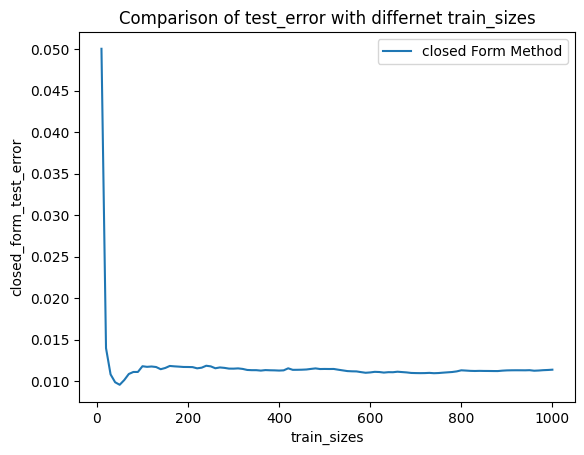

In [31]:

plt.plot(train_sizes, closed_form_test_error, label='closed Form Method')
plt.xlabel('train_sizes')
plt.ylabel('closed_form_test_error')
plt.title('Comparison of test_error with differnet train_sizes')
plt.legend()
plt.show()

In [38]:
theta_sgd,y_sgd,costs=stochastic_gradient_descent(X_train,y_train, 0.001, 100)

In [39]:
theta,y,costs=batch_gradient_descent(X_train,y_train, 0.001, 100)